# Pakistan Job Market Exploratory Data Analysis (EDA)

**Day 1 of 5: Pakistan Job Market Analyzer**

EDA = Exploratory Data Analysis. Before building any ML model or dashboard, we understand our data:
- What does it look like? (shape, columns, data types)
- How messy is it? (nulls, weird values)
- What patterns exist? (which skills, cities, salary ranges dominate)

In [1]:
import subprocess, sys

# Auto-install kaleido if missing (needed for PNG rendering on GitHub)
try:
    import kaleido
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kaleido", "-q"])

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pio.renderers.default = "png"

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Data

In [2]:
DATA_PATH = '../data/raw/RozeePK-Jobs-2024.csv'

df = pd.read_csv(DATA_PATH, encoding='utf-8')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 1,059 rows × 12 columns


,Title,Salary,Job Type,Job Location,Functional Area,Career Level,Apply Before,Minimum Experience,Minimum Education,Gender,Age,Skills
0,Order Fulfillment Manager,"PKR. 30,000 - 60,000/Month",Full Time/Permanent,"Lahore,\n ...",Retail,Experienced Professional,3-Jan-25,2 Years,Intermediate/A-Level,Male,NaN,"Team Building, Order Tracking, Order Processing, Order M..."
1,Enterprise Business Development Manager,NaN,Full Time/Permanent,"Lahore,\n ...",NaN,NaN,19-Jan-25,3 Years,NaN,No Preference,NaN,"Relationship Building, Sales Acumen, Market Research, Ne..."
2,Video Editor,"PKR. 30,000 - 30,000/Month",Full Time/Permanent,"Karachi,\n ...",NaN,NaN,19-Jan-25,1 Year,NaN,No Preference,NaN,Video Editor


## 3. Data Types & Memory Usage

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Title               1034 non-null   object
 1   Salary              745 non-null    object
 2   Job Type            1034 non-null   object
 3   Job Location        1034 non-null   object
 4   Functional Area     896 non-null    object
 5   Career Level        896 non-null    object
 6   Apply Before        1034 non-null   object
 7   Minimum Experience  747 non-null    object
 8   Minimum Education   863 non-null    object
 9   Gender              1034 non-null   object
 10  Age                 168 non-null    object
 11  Skills              1033 non-null   object
dtypes: object(12)
memory usage: 99.4+ KB


## 4. Missing Values Analysis
important for analyzing which columns to keep and which columns to drop. 
if 50 to 60% values are missing then we drop the column but if it's and important column like salary, we work with the available values.

In [4]:
# Standardize messy null representations
df.replace(['NA', 'N/A', 'n/a', 'na', '', ' '], np.nan, inplace=True)

# Strip whitespace from all string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

# Calculate missing % per column
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing %', ascending=False)

print(missing)
print(f'\nTotal rows: {len(df):,}')

                    Missing Count  Missing %
Age                           891       84.1
Salary                        314       29.7
Minimum Experience            312       29.5
Minimum Education             196       18.5
Career Level                  163       15.4
Functional Area               163       15.4
Skills                         26        2.5
Title                          25        2.4
Job Location                   25        2.4
Job Type                       25        2.4
Apply Before                   25        2.4
Gender                         25        2.4

Total rows: 1,059


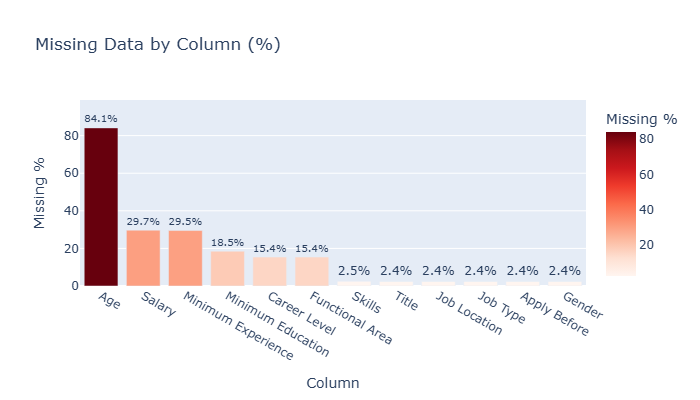

In [5]:
# Visualize missing data 
fig = px.bar(
    missing.reset_index(),
    x='index', y='Missing %',
    title='Missing Data by Column (%)',
    labels={'index': 'Column'},
    color='Missing %',
    color_continuous_scale='Reds',
    text='Missing %'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(showlegend=False, height=400)
fig.show()

## 5. Clean the Salary Column

Salary is currently a string like PKR. 30,000 - 60,000/Month. We need numbers.

Strategy: Use regex to extract the low and high values, then take their average.

Why regex? The salary strings aren't perfectly consistent — regex handles variations.

In [6]:
import re

def parse_salary(salary_str):
    """
    Converts a messy salary string into a numeric monthly PKR value.
    Returns NaN if parsing fails and never crashes on bad input.
    """

    if pd.isna(salary_str):
        return np.nan
    
    # Remove commas so '30,000' becomes '30000' bec we need strings
    cleaned = salary_str.replace(',', '')
    
    # Find all number sequences in the string
    numbers = re.findall(r'\d+', cleaned)
    
    if len(numbers) == 0:
        return np.nan
    elif len(numbers) == 1:
        return float(numbers[0])
    else:
        # Take average of low and high salary
        low, high = float(numbers[0]), float(numbers[1])
        return (low + high) / 2


df['salary_pkr'] = df['Salary'].apply(parse_salary)

# Quick sanity check
print('Salary column sample:')
print(df[['Salary', 'salary_pkr']].dropna().head(10).to_string())
print(f'\nSalaries parsed: {df["salary_pkr"].notna().sum()} / {len(df)}')

Salary column sample:
                          Salary  salary_pkr
0     PKR. 30,000 - 60,000/Month     45000.0
2     PKR. 30,000 - 30,000/Month     30000.0
3     PKR. 60,000 - 60,000/Month     60000.0
5     PKR. 85,000 - 85,000/Month     85000.0
6   PKR. 100,000 - 100,000/Month    100000.0
8   PKR. 100,000 - 150,000/Month    125000.0
9     PKR. 30,000 - 40,000/Month     35000.0
10   PKR. 35,000 - 100,000/Month     67500.0
11    PKR. 30,000 - 45,000/Month     37500.0
12    PKR. 30,000 - 40,000/Month     35000.0

Salaries parsed: 745 / 1059


In [7]:
# Remove extreme outliers using IQR method
# WHY: A salary of 1,000,000,000 PKR is clearly a data entry error
# IQR = Interquartile Range = the middle 50% of the data
# Anything beyond 1.5×IQR from Q1/Q3 is considered an outlier

sal = df['salary_pkr'].dropna()
Q1, Q3 = sal.quantile(0.25), sal.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap instead of drop — we keep the row, just remove the outlier salary
before = df['salary_pkr'].notna().sum()
df.loc[df['salary_pkr'] < lower_bound, 'salary_pkr'] = np.nan
df.loc[df['salary_pkr'] > upper_bound, 'salary_pkr'] = np.nan
after = df['salary_pkr'].notna().sum()

print(f'Outliers removed: {before - after}')
print(f'Salary range after cleaning: PKR {df["salary_pkr"].min():,.0f} — {df["salary_pkr"].max():,.0f}')
print(f'Median salary: PKR {df["salary_pkr"].median():,.0f}/month')

Outliers removed: 67
Salary range after cleaning: PKR 7,500 — 150,000
Median salary: PKR 52,500/month


## 6. Clean Location Column

The location column has newlines and extra whitespace`'Lahore,\n   Pakistan'`. We just want the city.

In [8]:
def extract_city(location_str):
    """Pulls out just the city name from messy location strings."""
    if pd.isna(location_str):
        return np.nan
    # Split on comma, take first part, strip whitespace/newlines
    city = location_str.split(',')[0].strip()
    return city if city else np.nan


df['city'] = df['Job Location'].apply(extract_city)

print('Top 15 cities:')
print(df['city'].value_counts().head(15))

Top 15 cities:
city
Lahore              215
Islamabad           191
Karachi             103
Johar Town           36
DHA                  26
Gulberg 3            22
Faisalabad           17
Gulshan-e-Iqbal      15
Pakistan             14
Rawalpindi           14
P.E.C.H.S            13
Jhelum               13
Multan               13
Gulberg              12
Gulistan-e-Johar     11
Name: count, dtype: int64


## 7. Clean Experience Column

`'2 Years'` → `2` (integer). We'll use regex again and extract just the leading number.

In [9]:
def parse_experience(exp_str):
    """Extracts numeric years from experience strings like '2 Years', '5+ Years'."""
    if pd.isna(exp_str):
        return np.nan
    match = re.search(r'(\d+)', str(exp_str))
    return float(match.group(1)) if match else np.nan


df['experience_years'] = df['Minimum Experience'].apply(parse_experience)

print('Experience distribution:')
print(df['experience_years'].value_counts().sort_index())

Experience distribution:
experience_years
1.0     222
2.0     154
3.0     140
4.0      36
5.0      70
6.0       5
7.0       7
8.0       7
10.0     15
12.0      1
13.0      1
14.0      1
15.0      4
20.0      1
Name: count, dtype: int64


## 8. Explode Skills Column

Skills look like: `'Python, SQL, Machine Learning, Pandas'`,  a comma-separated string.
We need to split these into individual skills to count them.
`explode()` is a pandas function that turns one row with a list into multiple rows one per item.

In [10]:
# Split comma-separated skills into lists, then explode into individual rows
skills_series = (
    df['Skills']
    .dropna() #skip rows with no skills
    .str.split(',') #"Python, SQL" = ["Python", "SQL"]
    .explode()
    .str.strip() #remove spaces
    .str.lower()            # normalize: 'Python' == 'python'
    .loc[lambda s: s != ''] # remove empty strings
)

top_skills = skills_series.value_counts().head(30)

print(f'Total unique skills found: {skills_series.nunique()}')
print('\nTop 30 skills:')
print(top_skills.to_string())

Total unique skills found: 1707

Top 30 skills:
Skills
communication skills                347
fluent in english                   114
sales management                     73
coordination skills                  69
admin operations management          54
javascript                           39
communication                        37
end to end sales                     36
time management                      34
problem solving                      33
customer satisfaction management     26
ms excel                             24
analytical skills                    24
data analysis                        24
telemarketing  skills                23
digital marketing management         23
presentation skills                  22
travels knowledge                    22
adobe illustrator                    21
leadership                           21
multitasking skills                  20
market research                      19
html                                 19
negotiation skills       

## 9. Visualizations
We use Plotly (not matplotlib) because:
- Interactive (hover, zoom, filter)
- Looks modern 

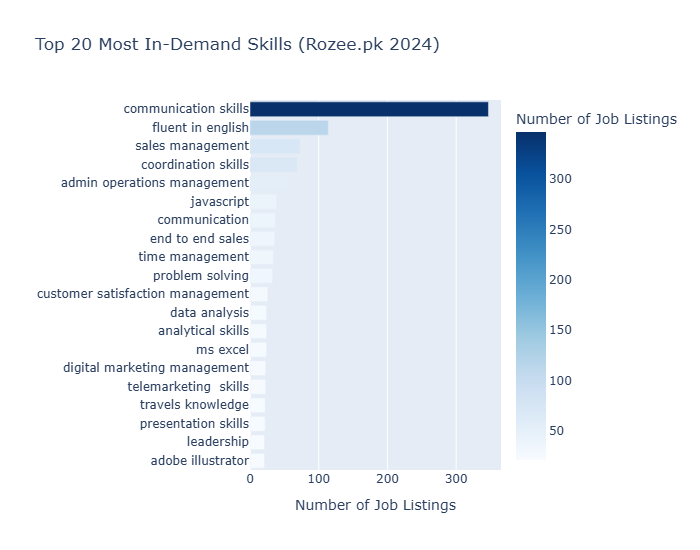

In [11]:
# Top 20 In-Demand Skills
fig = px.bar(
    top_skills.head(20).reset_index(),
    x='count', y='Skills',
    orientation='h',
    title='Top 20 Most In-Demand Skills (Rozee.pk 2024)',
    labels={'count': 'Number of Job Listings', 'Skills': ''},
    color='count',
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, showlegend=False, height=550)
fig.show()

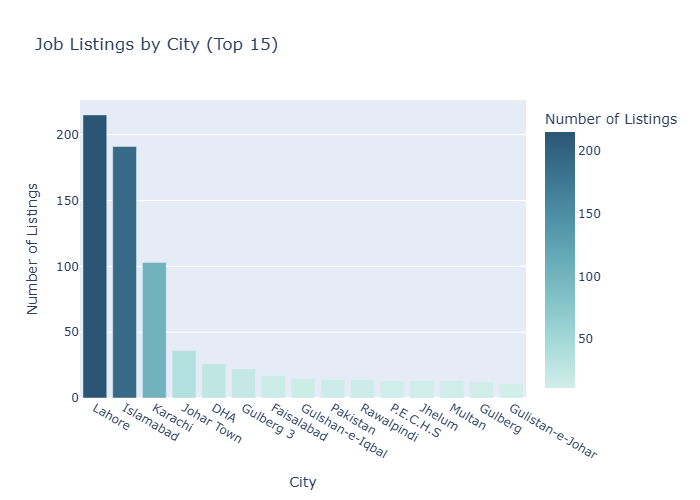

In [12]:
# Jobs by City
city_counts = df['city'].value_counts().head(15).reset_index()
city_counts.columns = ['city', 'count']

fig = px.bar(
    city_counts,
    x='city', y='count',
    title='Job Listings by City (Top 15)',
    labels={'city': 'City', 'count': 'Number of Listings'},
    color='count',
    color_continuous_scale='Teal'
)
fig.update_layout(showlegend=False)
fig.show()

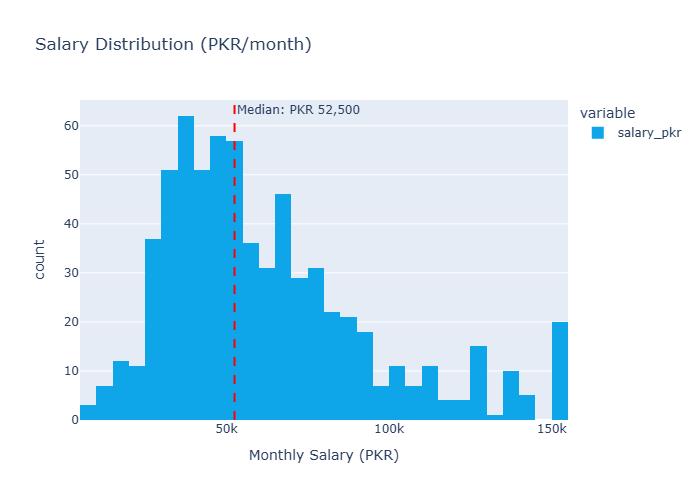

In [13]:
# Salary Distribution 
sal_data = df['salary_pkr'].dropna()

fig = px.histogram(
    sal_data,
    nbins=40,
    title='Salary Distribution (PKR/month)',
    labels={'value': 'Monthly Salary (PKR)', 'count': 'Number of Jobs'},
    color_discrete_sequence=['#0EA5E9']
)
fig.add_vline(
    x=sal_data.median(), line_dash='dash', line_color='red',
    annotation_text=f'Median: PKR {sal_data.median():,.0f}',
    annotation_position='top right'
)
fig.show()

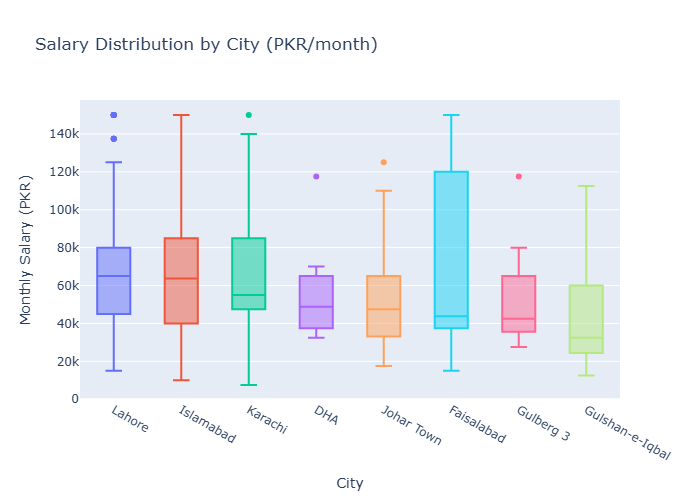

In [14]:
# Salary by City (Box Plot)
# Box plot shows median, spread, and outliers — more info than a bar chart
top_cities = df['city'].value_counts().head(8).index.tolist()
city_sal_df = df[df['city'].isin(top_cities) & df['salary_pkr'].notna()]

fig = px.box(
    city_sal_df,
    x='city', y='salary_pkr',
    title='Salary Distribution by City (PKR/month)',
    labels={'city': 'City', 'salary_pkr': 'Monthly Salary (PKR)'},
    color='city',
    category_orders={'city': city_sal_df.groupby('city')['salary_pkr'].median().sort_values(ascending=False).index.tolist()}
)
fig.update_layout(showlegend=False)
fig.show()

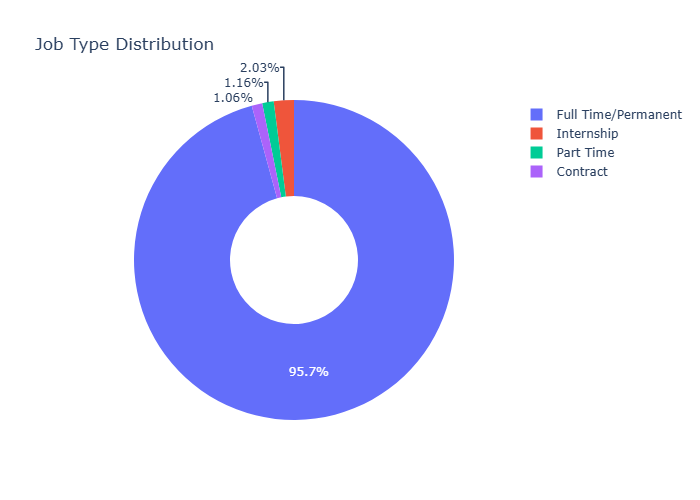

In [15]:
# Job Type Breakdown
job_type_counts = df['Job Type'].value_counts().reset_index()
job_type_counts.columns = ['Job Type', 'count']

fig = px.pie(
    job_type_counts,
    names='Job Type', values='count',
    title='Job Type Distribution',
    hole=0.4   # donut chart — cleaner than pie
)
fig.show()

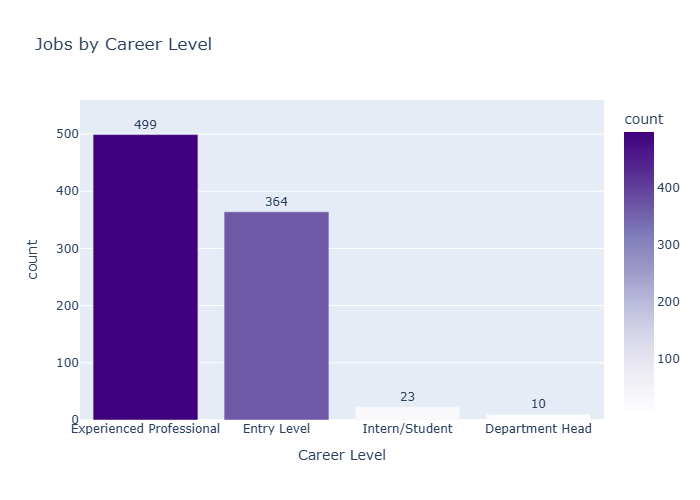

In [16]:
# Career Level Distribution
career_counts = df['Career Level'].value_counts().reset_index()
career_counts.columns = ['Career Level', 'count']

fig = px.bar(
    career_counts,
    x='Career Level', y='count',
    title='Jobs by Career Level',
    color='count',
    color_continuous_scale='Purples',
    text='count'
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

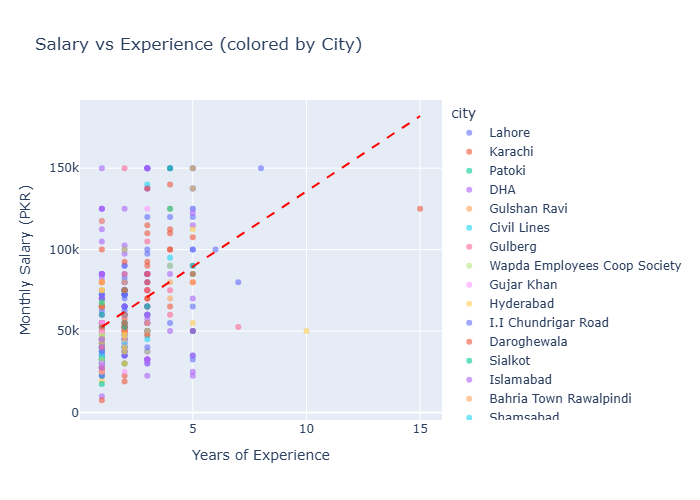

Trend: each extra year of experience adds PKR 9,247/month on average


In [17]:
# Salary vs Experience (Scatter)
# Does more experience = more pay in Pakistan?
scatter_df = df[df['salary_pkr'].notna() & df['experience_years'].notna()].copy()

# Fit a linear trend line manually with numpy
x_vals = scatter_df['experience_years'].values
y_vals = scatter_df['salary_pkr'].values
coeffs = np.polyfit(x_vals, y_vals, 1)          # returns [slope, intercept]
trend_x = np.linspace(x_vals.min(), x_vals.max(), 100)
trend_y = np.polyval(coeffs, trend_x)            # y = slope*x + intercept

fig = px.scatter(
    scatter_df,
    x='experience_years', y='salary_pkr',
    color='city',
    hover_data=['Title', 'city'],
    title='Salary vs Experience (colored by City)',
    labels={'experience_years': 'Years of Experience', 'salary_pkr': 'Monthly Salary (PKR)'},
    opacity=0.6
)

# Add the trend line as a separate trace
fig.add_scatter(
    x=trend_x, y=trend_y,
    mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name=f'Trend (slope: PKR {coeffs[0]:,.0f}/yr)'
)

fig.show()
print(f'Trend: each extra year of experience adds PKR {coeffs[0]:,.0f}/month on average')

## 10. Top Functional Areas (Industry Domains)

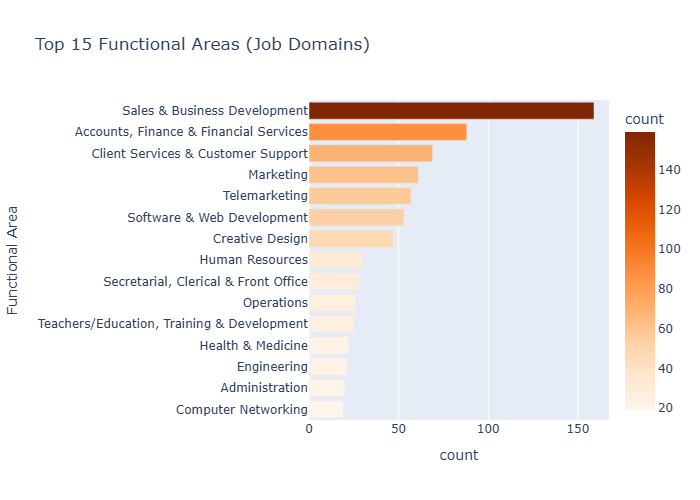

In [18]:
func_area_counts = df['Functional Area'].value_counts().head(15).reset_index()
func_area_counts.columns = ['Functional Area', 'count']

fig = px.bar(
    func_area_counts,
    x='count', y='Functional Area',
    orientation='h',
    title='Top 15 Functional Areas (Job Domains)',
    color='count',
    color_continuous_scale='Oranges'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, showlegend=False, height=500)
fig.show()

## 11. Save Cleaned Dataset

We save the cleaned DataFrame so Day 2 (ML model) can load it directly no need to re-clean.

In [19]:
PROCESSED_PATH = '../data/processed/jobs_cleaned.csv'

df.to_csv(PROCESSED_PATH, index=False)

print(f'Cleaned dataset saved to: {PROCESSED_PATH}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nNew columns added:')
print('  salary_pkr       — numeric monthly salary in PKR')
print('  city             — clean city name')
print('  experience_years — numeric years of experience')

Cleaned dataset saved to: ../data/processed/jobs_cleaned.csv
Shape: 1,059 rows × 15 columns

New columns added:
  salary_pkr       — numeric monthly salary in PKR
  city             — clean city name
  experience_years — numeric years of experience


## 12. Summary 

**Example findings:**
- Most jobs are in Lahore and Karachi
- Top skills: communication, MS Office, sales — but tech skills pay more
- Median salary: PKR X,XXX,XXX/month
- Salary and experience have a [weak/strong] positive correlation